<a href="https://colab.research.google.com/github/gravity102424/ESAA/blob/main/ESAA_OB_week12_2_NLP_VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 9. 자연어 처리
# 9.1 자연어 처리란
자연어 처리란 우리가 일상에서 사용하는 언어 의미를 분석하여 컴퓨터가 처리할 수 있도록 하는 과정이다. 자연어 처리는 딥러닝에 대한 이해도 필요하지만, 그에 앞서 인간 언어에 대한 이해도 필요하기 때문에 접근하기 어려운 분야다. 또한, 언어 종류가 다르고 그 형태가 다양하기 대문에 처리가 매우 어렵다. 예를 들어 영어는 명확한 띄어쓰기가 있지만, 중국어는 띄어쓰기가 없기 때문에 단어 단위의 임베딩이 어렵다. 또한, 자연어 처리를 위해 사용되는 용어들도 낯설다.

다음 그림은 자연어 처리가 가능한 영역과 발전이 필요한 분야다.

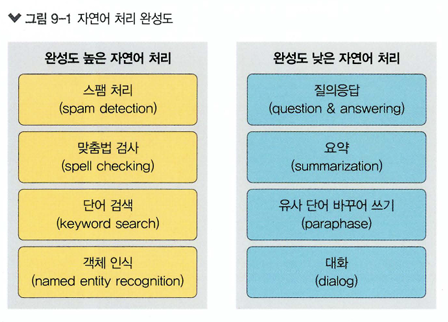

자연어 처리에서 사용하는 용어부터 알아보자.

## 9.1.1 자연어 처리 용어 및 과정
## 자연어 처리 관련 용어
* 말뭉치(corpus(코퍼스)): 자연어 처리에서 모델을 학습시키기 위한 데이터이며, 자연어 연구를 위해 특정한 목적에서 표본을 추출한 집합이다.

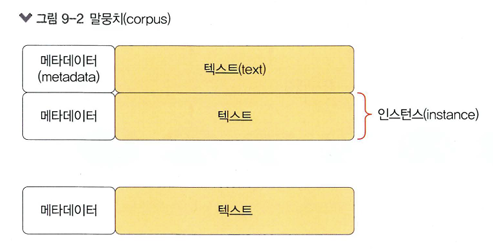

* 토큰(token): 자연어 처리를 위한 문서는 작은 단위로 나누어야 하는데, 이때 문서를 나누는 단위가 토큰이다. 문자열을 토큰으로 나누는 작업을 토큰 생성(tokenizing)이라고 하며, 문자열을 토큰으로 분리하는 함수를 토큰 생성 함수라고 한다.

* 토큰화(tokenization): 텍스트를 문장이나 단어로 분리하는 것을 의미한다. 토큰화 단계를 마치면 텍스트가 단어 단위로 분리된다.

* 불용어(stop words): 문장 내에서 많이 등장하는 단어이다. 분석과 관계없으며, 자주 등장하는 빈도 때문에 성능에 영향을 미치므로 사전에 제거해 주어야 한다. 불용어 예로 "a", "the", "she", "he" 등이 있다.

* 어간 추출(stemming): 단어를 기본 형태로 만드는 작업이다. 예를 들어 'consign', 'consigned', 'consigning', 'consignment'가 있을 때 기본 단어인 'consign'으로 통일하는 것이 어간 추출이다.

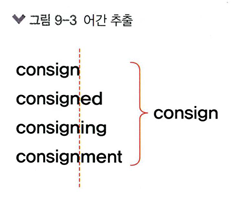


* 품사 태깅(part-of-speech tagging): 주어진 문장에서 품사를 식별하기 위해 붙여 주는 태그(식별 정보)를 의미한다.

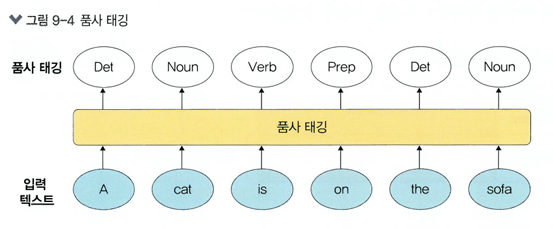


품사 태깅을 위한 정보는 다음과 같다.
* Det: 한정사
* Noun: 명사
* Verb: 동사
* Prep: 전치사
품사 태깅은 NLTK를 이용할 수 있다.

NLTK는 아나콘다가 설치되어 있다면 추가적으로 설치할 필요가 없지만, 책에서는 가상 환경에서 실습하므로 다음 명령으로 설치한다.



```
pip install nltk
```



품사 태깅을 위해 주어진 문장에 대해 토큰화를 먼저 진행한다. 다음 코드를 실행하면 NLTK Downloader 창이 뜬다. Download를 눌러 내려받는다.

In [2]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
text = nltk.word_tokenize("Is it possible distinguishing cats and dogs")
text

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


['Is', 'it', 'possible', 'distinguishing', 'cats', 'and', 'dogs']

In [3]:
# 태깅이 필요한 자원 내려받기

nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [4]:
# 품사 태깅

nltk.pos_tag(text)

[('Is', 'VBZ'),
 ('it', 'PRP'),
 ('possible', 'JJ'),
 ('distinguishing', 'VBG'),
 ('cats', 'NNS'),
 ('and', 'CC'),
 ('dogs', 'NNS')]

여기에서 사용되는 품사 의미는 다음과 같다.

* VBZ: 동사, 동명사 또는 현재 분사
* PRP: 인칭 대명사(pp)
* JJ: 형용사
* VBG: 동사, 동명사 또는 현재 분사
* NNS: 명사, 복수형
* CC: 등위 접속사

## 자연어 처리 과정

자연어는 인간 언어이다. 인간 언어는 컴퓨터가 이해할 수 없기 때문에 컴퓨터가 이해할 수 있는 언어로 바꾸고 원하는 결과를 얻기까지 크게 네 단계를 거친다.

1. 인간 언어인 자연어가 입력 텍스트로 들어오게 된다. 이때 인간 언어가 다양하듯 처리 방식이 조금씩 다르며, 현재는 영어에 대한 처리 방법들이 잘 알려져 있다.

2. 입력된 텍스트에 대한 전처리 과정이 필요하다.

3. 전처리가 끝난 단어들을 임베딩한다.

마지막으로 컴퓨터가 이해할 수 있는 데이터가 완성되었기 때문에 모델/모형을 이용하여 데이터에 대한 분류 및 예측을 수행한다. 이때 데이터 유형에 따라 분류와 예측에 대한 결과가 달라진다.

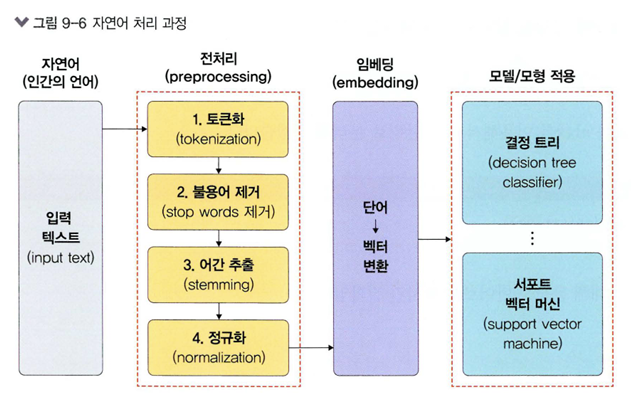


## 9.1.2 자연어 처리를 위한 라이브러리
## NLTK

NLTK(Natural Language ToolKit)는 교육용으로 개발된 자연어 처리 및 문서 분석용 파이썬 라이브러리이다. 다양한 기능 및 예제를 가지고 있으며 실무 및 연구에서도 많이 사용되고 있다.

다음은 NLTK 라이브러리가 제공하는 주요 기능이다.

* 말뭉치
* 토큰 생성
* 형태소 분석
* 품사 태깅



In [5]:
# nltk 라이브러리 호출 및 문장 정의

import nltk
nltk.download('punkt')
string1 = "my favorite subject is math"
string2 = "my favorite subject is math, english, economic and computer science"
nltk.word_tokenize(string1)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


['my', 'favorite', 'subject', 'is', 'math']

In [6]:
# 단어 단위로 분리

nltk.word_tokenize(string2)

['my',
 'favorite',
 'subject',
 'is',
 'math',
 ',',
 'english',
 ',',
 'economic',
 'and',
 'computer',
 'science']

## KoNLPy

KoNLPy는 한국어 처리를 위한 파이썬 라이브러리이다. KoNLPy는 파이썬에서 사용할 수 있는 오픈 소스 형태소 분석기로, 기존에 공개된 Kkma, Komoran, Hannanum, Twitter, Mecab 분석기를 한 번에 설치하고 동일한 방법으로 사용할 수 있도록 해 준다.

In [12]:
# 라이브러리 호출 및 문장을 형태소로 변환

from konlpy.tag import Komoran
komoran = Komoran()
print(komoran.morphs('딥러닝이 쉽나요? 어렵나요?')) # 텍스트를 형태소로 변환

['딥러닝이', '쉽', '나요', '?', '어렵', '나요', '?']


In [13]:
# 품사 태깅

print(komoran.pos('소파 위에 있는 것이 고양이인가요? 강아지인가요?')) # 텍스트에서 품사를 태깅하여 반환

[('소파', 'NNP'), ('위', 'NNG'), ('에', 'JKB'), ('있', 'VV'), ('는', 'ETM'), ('것', 'NNB'), ('이', 'JKS'), ('고양이', 'NNG'), ('이', 'VCP'), ('ㄴ가요', 'EF'), ('?', 'SF'), ('강아지', 'NNG'), ('이', 'VCP'), ('ㄴ가요', 'EF'), ('?', 'SF')]


KoNLPy에서 제공하는 주요 기능은 다음과 같다.

* 형태소 분석
* 품사 태깅

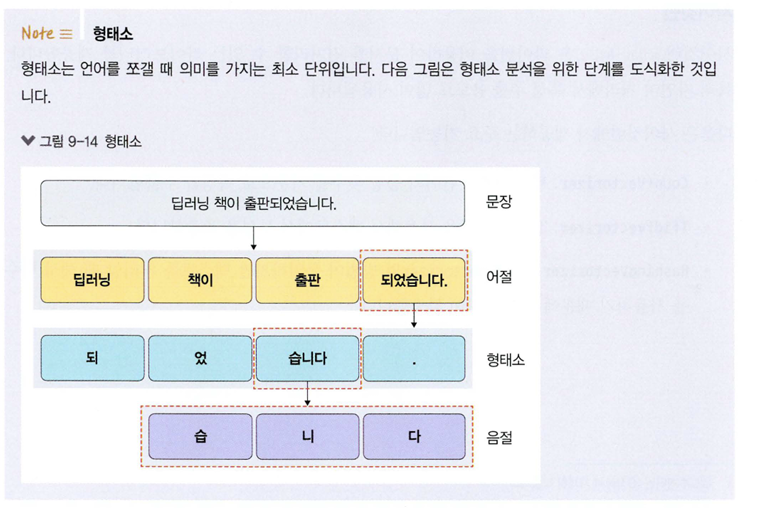

## Gensim

Gensim은 파이썬에서 제공하는 Word2Vec 라이브러리이다. 딥러닝 라이브러리는 아니지만 효율적이고 확장 가능하기 때문에 폭넓게 사용하고 있다.

다음은 Gensim에서 제공하는 주요 기능이다.

* 임베딩: 워드투벡터
* 토픽 모델링
* LDA

## 사이킷런

사이킷런은 파이썬을 이용하여 문서를 전처리할 수 있는 라이브러리를 제공한다. 특히 자연어 처리에서 특성 추출 용도로 많이 사용된다.

* CountVectorizer: 텍스트에서 단어의 등장 횟수를 기준으로 특성을 추출한다.
* Tfidfvectorizer: TF-IDF 값을 사용해서 텍스트에서 특성을 추출한다.
* HashingVectorizer: CountVectorizer와 방법이 동일하지만 텍스트를 처리할 때 해시 함수를 사용하기 때문에 실행 시간이 감소한다.

# 13.1 생성 모델이란

생성 모델(generative model)은 주어진 데이터를 학습하여 데이터 분포를 따르는 유사한 데이터를 생성하는 모델이다. 그럼 유사한 데이터는 어떻게 만들고, 생성 모델의 유형은 어떤 것들이 있는지 알아보자.

## 13.1.1 생성 모델 개념

기존 합성곱 신경망에서 다룬 이미지 분류, 이미지 검출 등은 입력 이미지($x$)가 있을 때 그에 따른 정답($y$)를 찾는 것이었다. 예를 들어 개와 고양이 이미지 데이터셋이 주어졌을 때, 그 이미지를 개와 고양이로 분류하는 문제들을 다루었다. 이렇게 이미지를 분류하는 것을 '판별(자) 모델(discriminative model)'이라고 한다. 일반적으로 판별자 모델에서는 이미지를 정확히 분류(구별)하고자 해당 이미지를 대표하는 특성들을 잘 찾는 것을 목표로 한다. 예를 들어 개와 고양이를 구별하려면 개의 귀, 꼬리 등 특성을 찾는 것이 중요하다.

그리고 판별자 모델에서 추출한 특성들의 조합을 이용하여 새로운 개와 고양이 이미지를 생성할 수 있는데, 이것을 '생성(자) 모델'이라고 한다. 즉, 생성 모델은 입력 이미지에 대한 데이터 분포 $p(x)$를 학습하여 새로운 이미지를 생성하는 것을 목표로 한다.

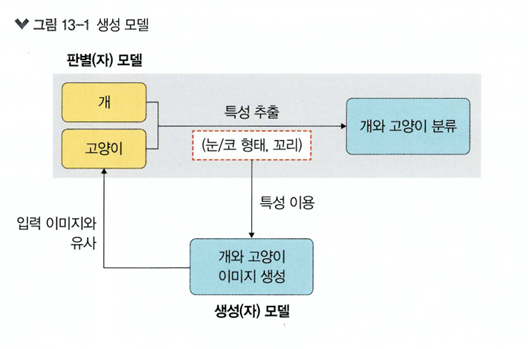

## 13.1.2 생성 모델의 유형

생성 모델의 유형에는 다음 그림과 같이 모델의 확률 변수를 구하는 '변형 오토인코더 모델'과 확률 변수를 이용하지 않는 'GAN 모델'이 있다.

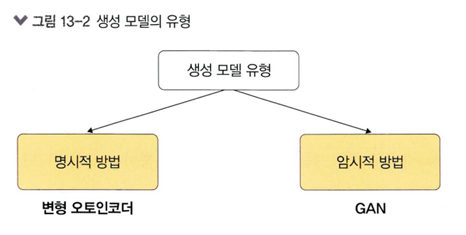


다시 정리하면 생성 모델은 크게 명시적 방법과 암시적 방법으로 분류할 수 있다. 명시적 방법은 확률 변수 $p(x)$를 정의하여 사용한다. 대표적인 모델로 변형 오토인코더가 있다. 암시적 방법은 확률 변수 $p(x)$에 대한 정의 없이 $p(x)$를 샘플링하여 사용한다. 대표적인 모델로 GAN이 있다.

변형 오토인코더는 이미지의 잠재 공간에서 샘플링하여 완전히 새로운 이미지나 기존 이미지를 변형하는 방식으로 학습을 진행한다. GAN은 생성자와 판별자가 서로 경쟁하면서 가짜 이미지를 진짜 이미지와 최대한 비슷하게 만들도록 학습을 진행한다.

변형 오토인코더부터 살펴보자.

# 13.2 변형 오토인코더

변형 오토인코더는 오토인코더의 확장이다.

## 13.2.1 오토인코더란

오토인코더는 단순히 입력을 출력으로 복사하는 신경망으로 은닉층(혹은 병목층이라고도 함)의 노드 수가 입력 값보다 적은 것이 특징이다. 따라서 입력과 출력이 동일한 이미지라고 예상할 수 있다. 하지만 왜 입력을 출력으로 복사하는 방법을 사용할까? 바로 은닉층 때문이다. 오토인코더의 병목층은 입력과 출력의 뉴런보다 훨씬 적다. 즉, 적은 수의 병목층 뉴런으로 데이터를 가장 잘 표현할 수 있는 방법이 오토인코더이다. 오토인코더는 네 가지 주요 부분으로 구성된다.

1. 인코더: 인지 네트워크라고도 하며, 특성에 대한 학습을 수행하는 부분이다.

2. 병목층(은닉층): 모델의 뉴런 개수가 최소인 계층이다. 이 계층에서는 차원이 가장 낮은 입력 데이터의 압축 표현이 포함된다.

3. 디코더: 생성 네트워크라고도 하며, 이 부분은 병목층에서 압축된 데이터를 원래대로 재구성하는 역할을 한다. 즉, 최대한 입력에 가까운 출력을 생성하도록 한다.

4. 손실 재구성: 오토인코더는 다음 그림과 같이 입력층과 출력층의 뉴런 개수가 동일하다는 것만 제외하면 일반적인 다층 퍼셉트론과 구조가 동일하다. 오토인코더는 압축된 입력을 출력층에서 재구성하며, 손실 함수는 입력과 출력(인코더와 디코더)의 차이를 가지고 계산한다.

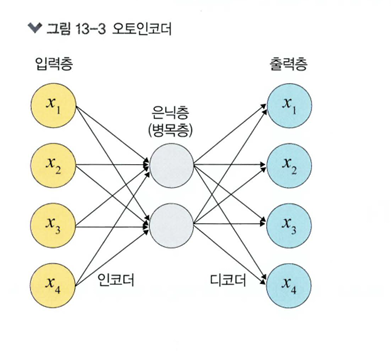

오토인코더 개념을 이해했다면 이번에는 수학적으로 접근해 보겠다.

입력 $x$와 출력 $y$는 같은 차원($R_d$)에 존재한다는 가정하에 입력 데이터를 인코더 네트워크에 통과시켜 압축된 잠재 벡터 $z$ 값을 얻는다. 이때 $z$를 구하는 공식은 다음과 같다.

$z$ = $h(x)$

압축된 $z$ 벡터에서 입력 데이터와 크기가 같은 출력 값은 다음과 같이 계산한다.

$y$ = $g(z)$ = $g(h(x))$

이때 손실 값은 입력 값 $x$과 디코더를 통과한 $y$ 값의 차이로 다음과 같이 계산한다.

$Loss$ = $\sum_{x\subseteqq D}^{}L(x,g(h(x)))$ = $\left\| x-y\right\|^2$


즉, 디코더 네트워크를 통과한 출력 값은 입력 값의 크기와 같아야 한다.

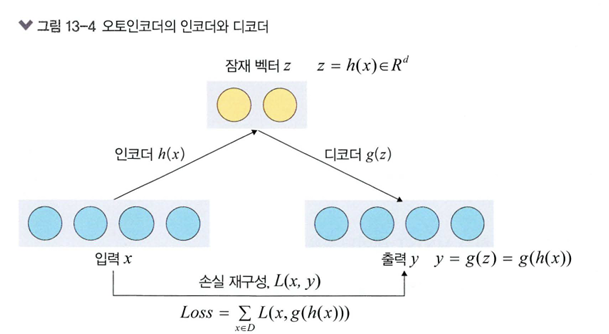


오토인코더가 중요한 이유는 다음 세 가지 때문이다.

1. 데이터 압축: 데이터 압축은 메모리 측면에서 상당한 장점이다. 오토인코더를 이용하여 이미지나 음성 파일의 중요 특성만 압축하면 용량도 작고 품질도 더 좋아진다.

2. 차원의 저주 예방: 차원의 저주 문제를 예방할 수 있다. 오토인코더는 특성 개수를 줄여 주기 때문에 데이터 차원이 감소하여 차원의 저주를 피할 수 있다.

3. 특성 추출: 오토인코더는 비지도 학습으로 자동으로 중요한 특성을 찾아 준다.

이제 파이토치에서 오토인코더를 구현해 볼 텐데 그동안 진행했던 모댈과는 다르게 조금 복잡할 수 있으니 반드시 예제를 실습하면서 이해해야 한다.
예제는 다음 그림과 같은 구조의 오토인코더를 사용한다.

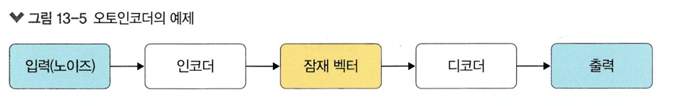

In [1]:
# 라이브러리 호출

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pylab as plt

import torchvision.datasets as datasets
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# MNIST 데이터셋을 내려받아 전처리

transform = transforms.Compose([transforms.ToTensor()]) # transforms.ToTensor()는 이미지를 파이토치의 텐서 형태로 변형시켜 준다.

train_dataset = datasets.MNIST(root='080289/chap13/data', train=True, download=True, transform=transform) # MNIST를 내려받은 후 텐서 형태로 변형

test_dataset = datasets.MNIST(root='080289/chap13/data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size = 128, shuffle = True, num_workers=4, pin_memory=False) # 1

test_loader = DataLoader(test_dataset, batch_size = 128, shuffle = False, num_workers=4)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 340kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.14MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.34MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


1. 데이터로더는 전체 데이터셋을 작은 단위로 쪼개서 메모리로 가져올 때 사용한다. 데이터로더에서 사용하는 파라미터는 다음과 같다.

a. 첫 번째 파라미터: 훈련 데이터셋

b. batch_size: 메모리로 한 번에 불러올 데이터의 크기

c. shuffle: True로 지정하면 데이터를 무작위로 섞겠다는 의미이다.

d. num_workers: 데이터를 불러올 때 몇 개의 프로세스를 사용할지 지정하는 부분으로 병렬로 데이터를 불러오겠다는 의미이다. 일반적으로 GPU를 사용할 때 많이 사용하는 파라미터이다. 너무 많은 값을 할당하면 오버헤드가 발생할 수 있고 작게 할당하면 좋은 성능을 기대할 수 있으므로 적절한 값을 지정해야 한다. 일반적으로 '4 * GPU 개수'를 지정하지만 모든 상황에 적합한 것은 아니므로 주의해서 시용할 필요가 있다.

e. pin_memory: CPU를 사용하다 GPU로 전환할 때 속도 향상을 위해 사용한다. 따라서 모델 훈련 과정에서 CPU나 GPU만 사용한다면 True로 지정할 필요가 없는 파라미터이다. pin_memory를 True로 지정하면 훈련에 사용할 데이터셋을 GPU에 미리 불러와서 학습시키기 때문에 속도가 향상된다.

이제 모델의 네트워크를 생성해 볼 텐데 인코더와 디코더를 사용하여 간단한 오토인코더를 만들어 보자. 이때 데이터셋을 저차원으로 압축하는 것을 인코더라고 하며, 압축된 것을 다시 원래의 차원으로 복원하는 것을 디코더라고 한다. 따라서 인코더와 디코더에서 사용하는 네트워크 계층은 같아야 한다.

In [4]:
# 네트워크(신경망) 생성

class Encoder(nn.Module): # 인코더 네트워크 생성
  def __init__(self, encoded_space_dim, fc2_input_dim):
    super().__init__()

    self.encoder_cnn = nn.Sequential(
        nn.Conv2d(1, 8, 3, stride = 2, padding = 1),
        nn.ReLU(True),
        nn.Conv2d(8, 16, 3, stride = 2, padding = 1),
        nn.BatchNorm2d(16),
        nn.ReLU(True),
        nn.Conv2d(16, 32, 3, stride = 2, padding = 0),
        nn.ReLU(True)
    ) # 이미지 데이터셋 처리를 위해 합성곱 신경망 이용

    self.flatten = nn.Flatten(start_dim = 1) # 완전연결층
    self.encoder_lin = nn.Sequential(
        nn.Linear(3*3*32, 128),
        nn.ReLU(True),
        nn.Linear(128, encoded_space_dim)
    ) # 출력 계층

  def forward(self, x):
    x = self.encoder_cnn(x)
    x = self.flatten(x)
    x = self.encoder_lin(x)
    return x

class Decoder(nn.Module): # 디코더 네트워크 생성
  def __init__(self, encoded_space_dim, fc2_input_dim):
    super().__init__()
    self.decoder_lin = nn.Sequential(
        nn.Linear(encoded_space_dim, 128),
        nn.ReLU(True),
        nn.Linear(128, 3*3*32),
        nn.ReLU(True)
    ) # 인코더의 출력을 디코더의 입력으로 사용

    self.unflatten = nn.Unflatten(dim=1,
                                  unflattened_size=(32, 3, 3)) # 인코더의 완전연결층에 대응
    self.decoder_conv = nn.Sequential(
        nn.ConvTranspose2d(32, 16, 3, stride = 2, output_padding = 0),
        nn.BatchNorm2d(16),
        nn.ReLU(True),
        nn.ConvTranspose2d(16, 8, 3, stride = 2, padding = 1, output_padding = 1),
        nn.BatchNorm2d(8),
        nn.ReLU(True),
        nn.ConvTranspose2d(8, 1, 3, stride = 2, padding = 1, output_padding = 1)
    ) # 인코더의 합성곱층에 대응

  def forward(self, x):
    x = self.decoder_lin(x)
    x = self.unflatten(x)
    x = self.decoder_conv(x)
    x = torch.sigmoid(x)
    return x

In [5]:
# 손실 함수와 옵티마이저 지정

encoder = Encoder(encoded_space_dim=4, fc2_input_dim=128)
decoder = Decoder(encoded_space_dim=4, fc2_input_dim=128)
encoder.to(device)
decoder.to(device)

params_to_optimize = [
    {'params': encoder.parameters()},
    {'params': decoder.parameters()}
] # 인코더와 디코더에서 사용할 파라미터를 다르게 지정

optim = torch.optim.Adam(params_to_optimize, lr=0.001, weight_decay=1e-05)
loss_fn = torch.nn.MSELoss()

오토인코더에서 가장 널리 시용되는 손실 함수는 '평균 제곱 오차'와 '이진 크로스 엔트로피'이다. 입력 값이 (0,1) 범위에 있으면 이진 크로스 엔트로피를 사용하고， 그렇지 않으면 평균 제곱 오치를 사용한다. 옵티마이저는 아담을 사용했지만 RMSProp 또는 adadelta 같은 옵티마이저를 이용하여 성능을 비교해 보는 것도 학습에 도움이 많이 되니, 옵션을 변경하여 테스트를 진행해 보자.

In [7]:
# 모델 학습 함수 생성

def train_epoch(encoder, decoder, device, dataloader, loss_fn, optimizer, noise_factor=0.3):
  encoder.train() # 인코더 훈련
  decoder.train() # 디코더 훈련
  train_loss = []
  for image_batch, _ in dataloader: # 훈련 데이터셋을 이용하여 모델 학습(비지도 학습으로 레이블은 필요하지 않다)
    image_noisy = add_noise(image_batch, noise_factor)
    image_noisy = image_noisy.to(device) # 데이터셋이 CPU/GPU 장치를 사용하도록 지정
    encoded_data = encoder(image_noisy) # 노이즈 데이터를 인코더의 입력으로 사용
    decoded_data = decoder(encoded_data) # 인코더 출력을 디코더의 입력으로 사용
    loss = loss_fn(decoded_data, image_noisy)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_loss.append(loss.detach().cpu().numpy())
  return np.mean(train_loss)

In [8]:
# 모델 테스트 함수 생성

def test_epoch(encoder, decoder, device, dataloader, loss_fn, noise_factor=0.3):
  # Set evaluation mode for encoder and decoder
  encoder.eval() # 인코더 테스트
  decoder.eval() # 디코더 데스트
  with torch.no_grad():
    conc_out = [] # 각 배치에 대한 출력을 저장하기 위해 리스트 형식의 변수 정의
    conc_label = []
    for image_batch, _ in dataloader:
      image_batch = image_batch.to(device)
      encoded_data = encoder(image_batch)
      decoded_data = decoder(encoded_data)
      conc_out.append(decoded_data.cpu())
      conc_label.append(image_batch.cpu())
    conc_out = torch.cat(conc_out) # 리스트 형식으로 저장된 모든 값을 하나의 텐서로 생성
    conc_label = torch.cat(conc_label)
    val_loss = loss_fn(conc_out, conc_label) # 손실 함수를 이용하여 오차 계산
  return val_loss.data

In [9]:
# 노이즈 데이터 생성

def add_noise(inputs, noise_factor=0.3):
  noisy = inputs + torch.randn_like(inputs) * noise_factor # 1
  noisy = torch.clip(noisy, 0., 1.) # 2
  return noisy

1. torch.randn_like(inputs)는 입력과 동일한 크기의 노이즈 텐서를 생성하고자 할 때 사용한다.

2. torch.clip은 데이터 값의 범위를 조정할 때 사용한다.

In [10]:
# 한글 깨짐 문제 해결

!apt-get -qq install fonts-nanum
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_family = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['font.family'] = font_family

Selecting previously unselected package fonts-nanum.
(Reading database ... 118212 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [12]:
# 이미지 시각화

def plot_ae_outputs(encoder, decoder, n=5, noise_factor=0.3):
  plt.figure(figsize = (10, 4.5))
  for i in range(n):
    ax = plt.subplot(3, n, i+1) # subplot에서 사용하는 파라미터는 (행, 열, 인덱스)입니다. 3x5 형태의 이미지가 출력된다.
    img = test_dataset[i][0].unsqueeze(0)
    image_noisy = add_noise(img, noise_factor)
    image_noisy = image_noisy.to(device)

    encoder.eval()
    decoder.eval()
    with torch.no_grad():
      rec_img = decoder(encoder(image_noisy))

    plt.imshow(img.cpu().squeeze().numpy(), cmap='gist_gray') # 테스트 데이터셋을 출력
    ax.get_xaxis().set_visible(False) # set_visible(False)는 그래프의 눈금을 표시하지 않겠다는 의미
    ax.get_yaxis().set_visible(False)
    if i == n//2:
      ax.set_title('원래 이미지')
    ax = plt.subplot(3, n, i+1+n)
    plt.imshow(image_noisy.cpu().squeeze().numpy(), cmap='gist_gray') # 테스트 데이터셋에 노이즈가 적용된 결과를 출력
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if 1 == n//2:
      ax.set_title('노이즈가 적용되어 손상된 이미지')

    ax = plt.subplot(3, n, i+1+n+n)
    plt.imshow(rec_img.cpu().squeeze().numpy(), cmap='gist_gray') # 노이즈가 추가된 이미지를 인코더와 디코더에 적용한 결과를 출력
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == n//2:
      ax.set_title('재구성된 이미지')
  plt.subplots_adjust(left =0.1, bottom=0.1, right=0.7,
                      top=0.9, wspace = 0.3, hspace = 0.3) # subplots_adjust()를 이용하여 subplot들이 겹치지 않도록 최소한의 여백을 만들어 준다.
  plt.show()

EPOCH 1/30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) m


 EPOCH 1/30 	 train loss 0.084 	 val loss 0.059


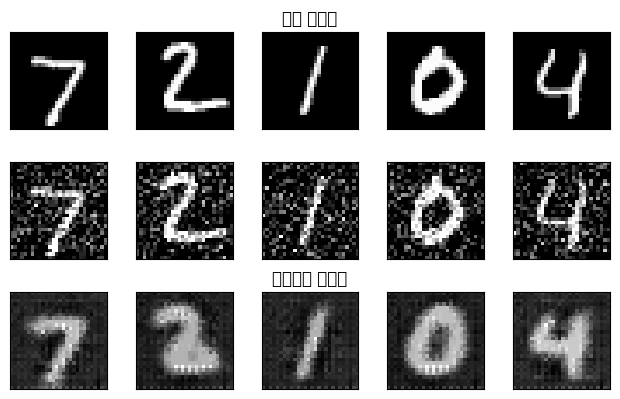

EPOCH 2/30



 EPOCH 2/30 	 train loss 0.058 	 val loss 0.046


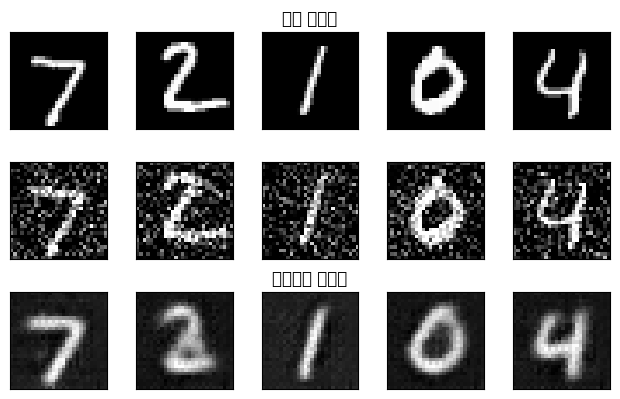

EPOCH 3/30



 EPOCH 3/30 	 train loss 0.053 	 val loss 0.043


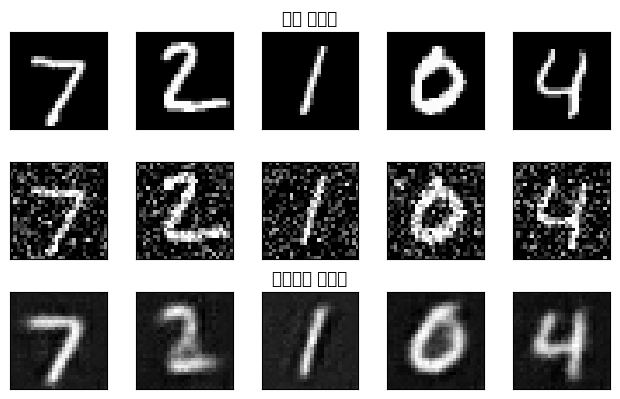

EPOCH 4/30



 EPOCH 4/30 	 train loss 0.052 	 val loss 0.042


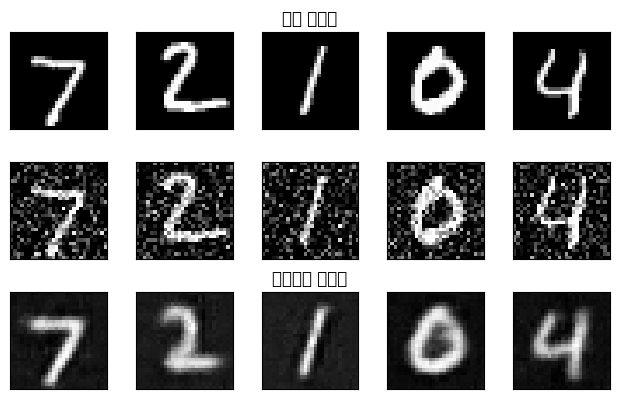

EPOCH 5/30

 EPOCH 5/30 	 train loss 0.052 	 val loss 0.041


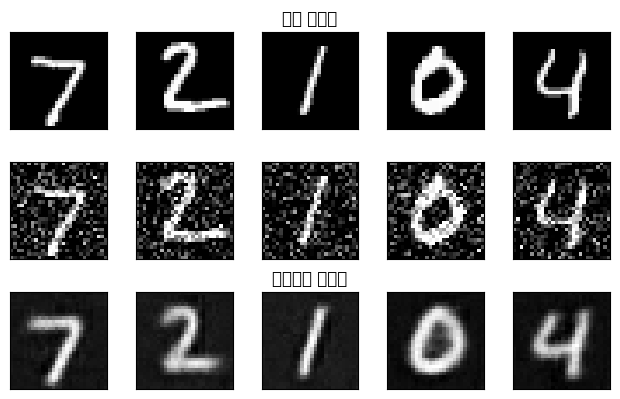

EPOCH 6/30



 EPOCH 6/30 	 train loss 0.051 	 val loss 0.041


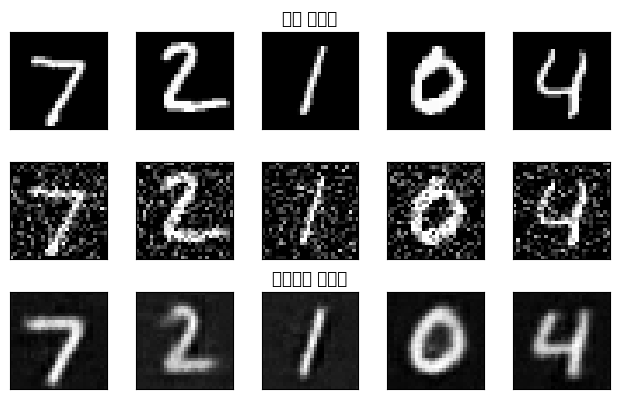

EPOCH 7/30



 EPOCH 7/30 	 train loss 0.051 	 val loss 0.040


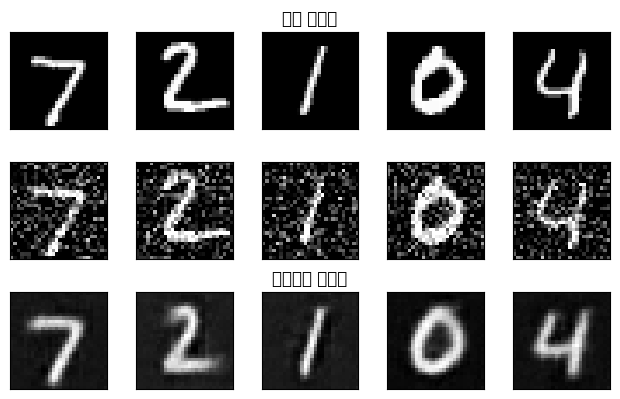

EPOCH 8/30



 EPOCH 8/30 	 train loss 0.051 	 val loss 0.040


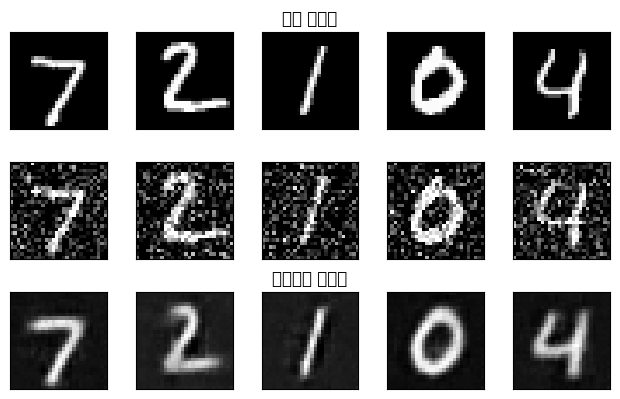

EPOCH 9/30

 EPOCH 9/30 	 train loss 0.051 	 val loss 0.039


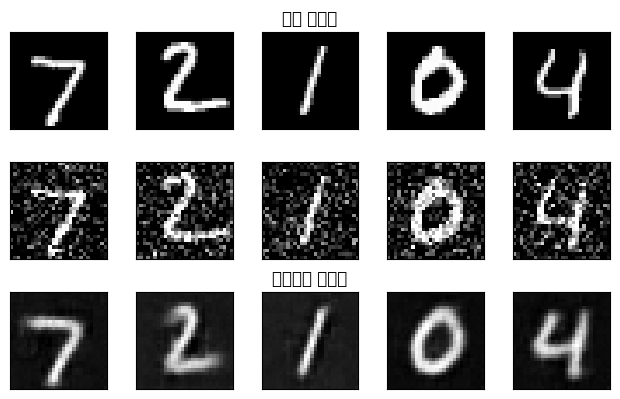

EPOCH 10/30



 EPOCH 10/30 	 train loss 0.050 	 val loss 0.040


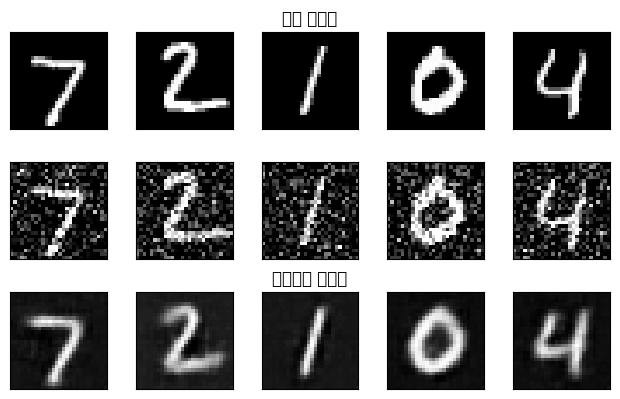

EPOCH 11/30



 EPOCH 11/30 	 train loss 0.050 	 val loss 0.039


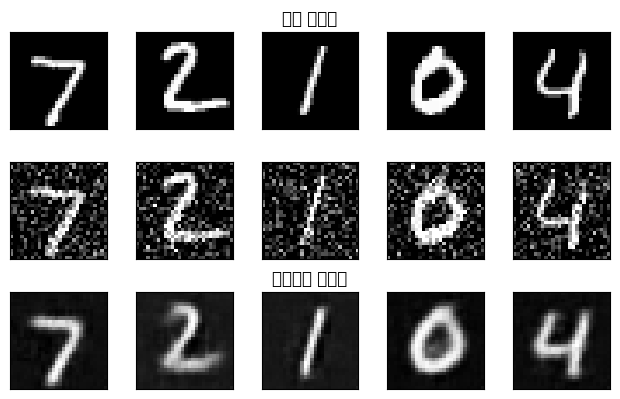

EPOCH 12/30



 EPOCH 12/30 	 train loss 0.050 	 val loss 0.039


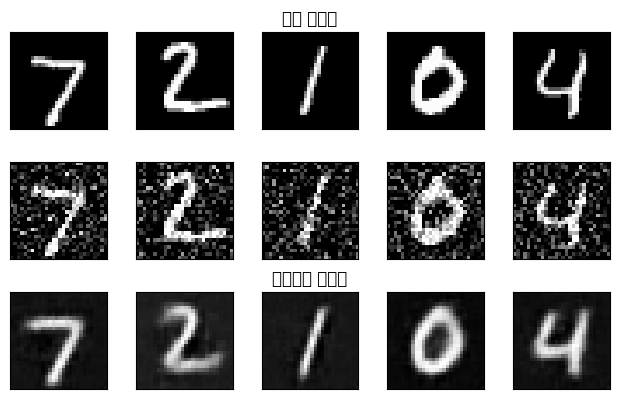

EPOCH 13/30



 EPOCH 13/30 	 train loss 0.050 	 val loss 0.039


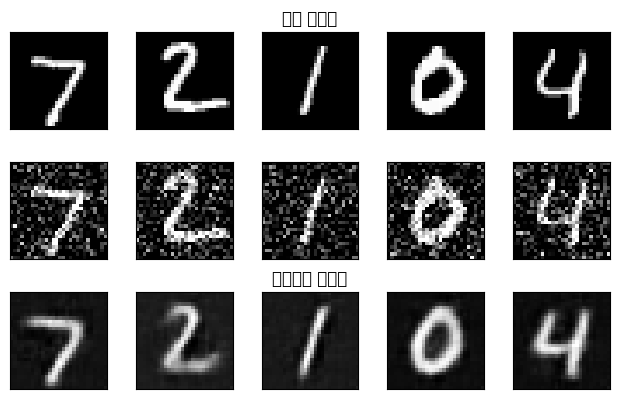

EPOCH 14/30

 EPOCH 14/30 	 train loss 0.050 	 val loss 0.039


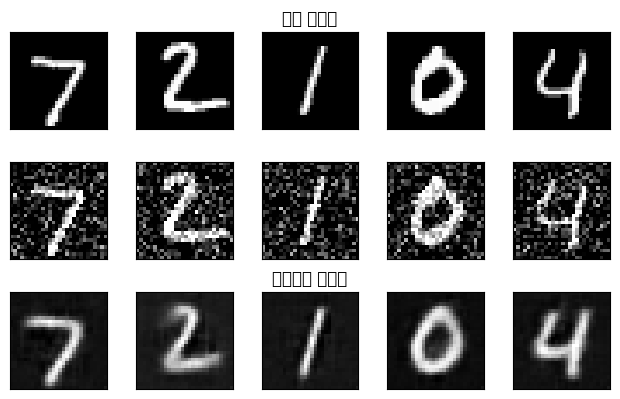

EPOCH 15/30



 EPOCH 15/30 	 train loss 0.050 	 val loss 0.038


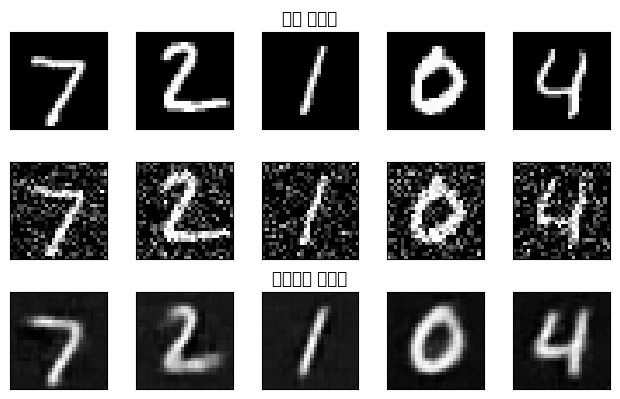

EPOCH 16/30



 EPOCH 16/30 	 train loss 0.050 	 val loss 0.039


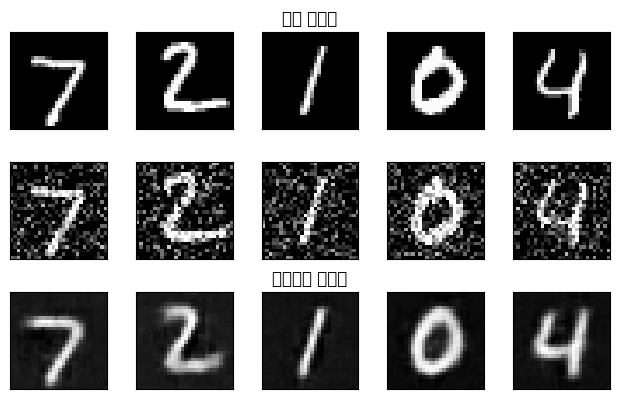

EPOCH 17/30



 EPOCH 17/30 	 train loss 0.050 	 val loss 0.038


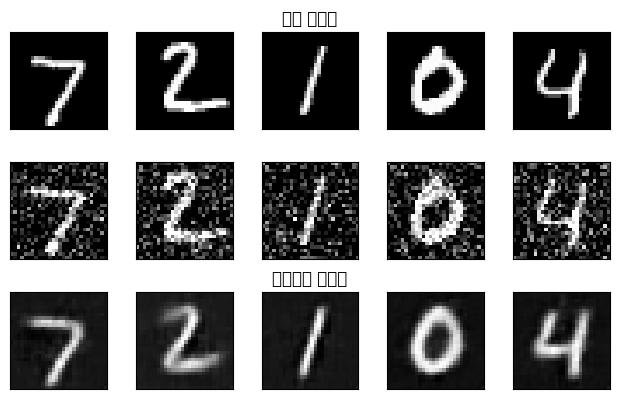

EPOCH 18/30

 EPOCH 18/30 	 train loss 0.050 	 val loss 0.039


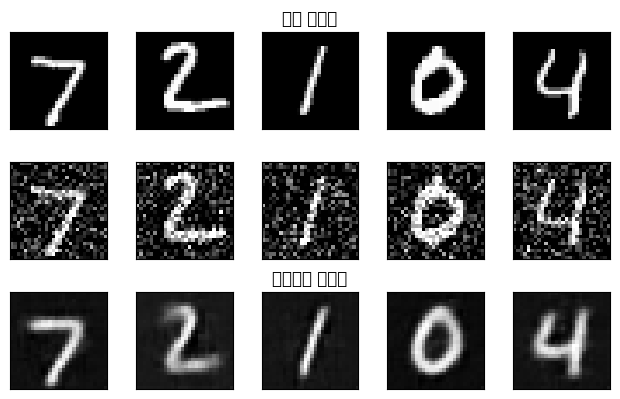

EPOCH 19/30



 EPOCH 19/30 	 train loss 0.050 	 val loss 0.039


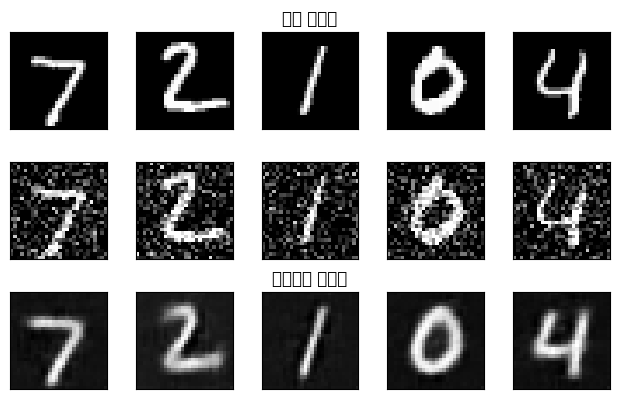

EPOCH 20/30



 EPOCH 20/30 	 train loss 0.050 	 val loss 0.038


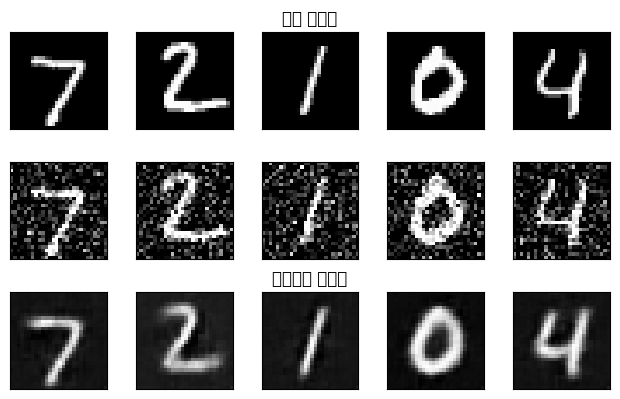

EPOCH 21/30



 EPOCH 21/30 	 train loss 0.050 	 val loss 0.038


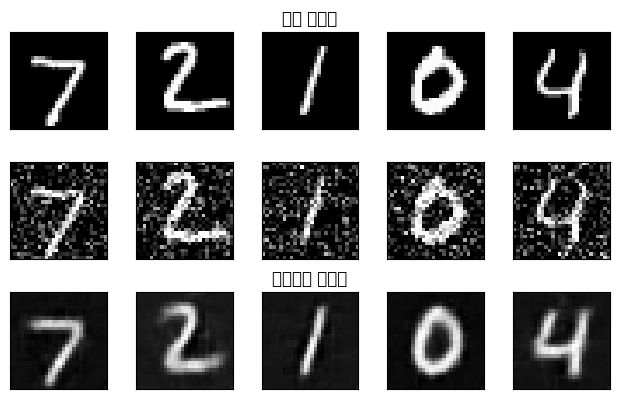

EPOCH 22/30



 EPOCH 22/30 	 train loss 0.050 	 val loss 0.038


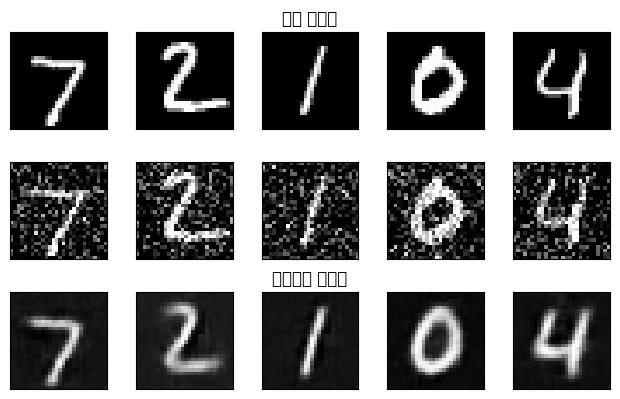

EPOCH 23/30

 EPOCH 23/30 	 train loss 0.050 	 val loss 0.038


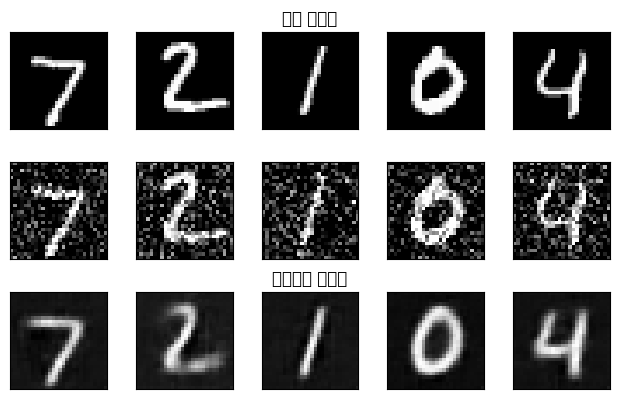

EPOCH 24/30



 EPOCH 24/30 	 train loss 0.049 	 val loss 0.038


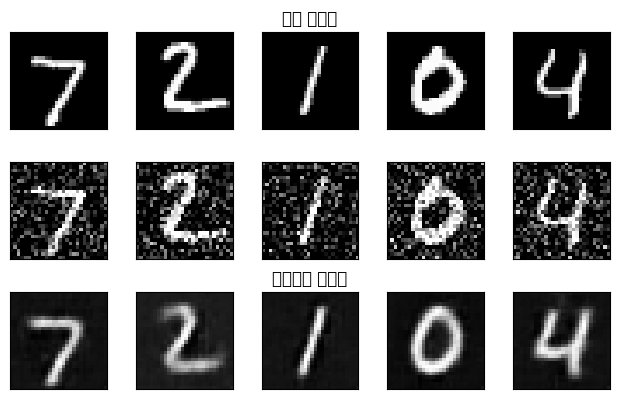

EPOCH 25/30



 EPOCH 25/30 	 train loss 0.049 	 val loss 0.038


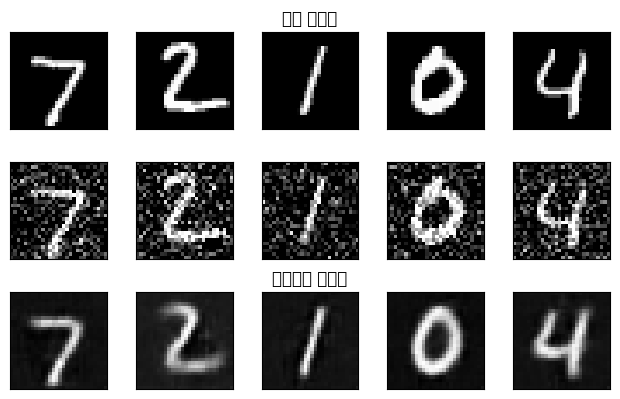

EPOCH 26/30



 EPOCH 26/30 	 train loss 0.049 	 val loss 0.038


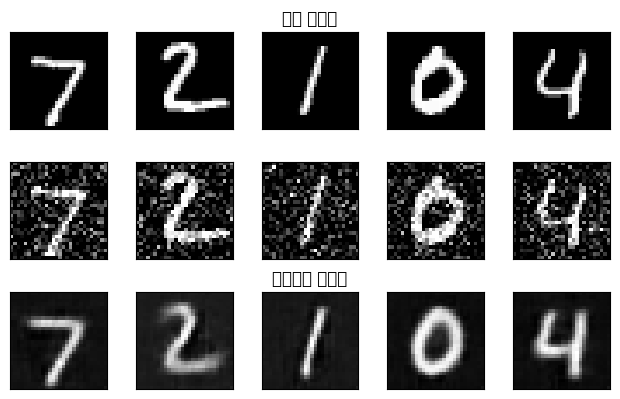

EPOCH 27/30

 EPOCH 27/30 	 train loss 0.049 	 val loss 0.038


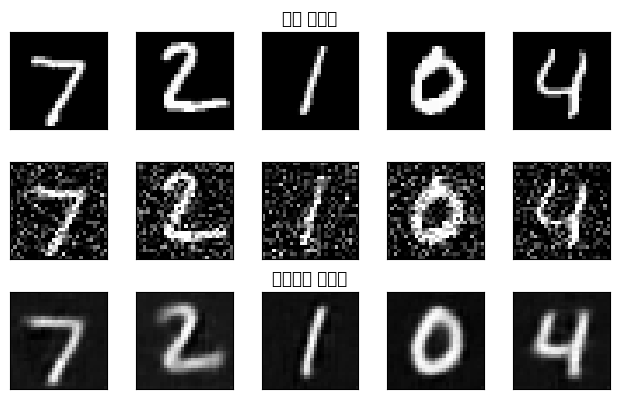

EPOCH 28/30



 EPOCH 28/30 	 train loss 0.049 	 val loss 0.038


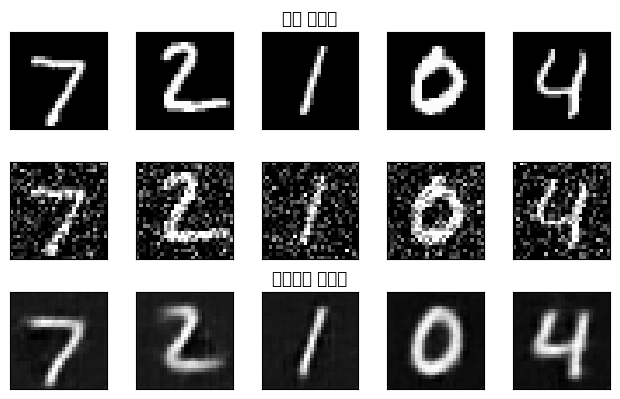

EPOCH 29/30



 EPOCH 29/30 	 train loss 0.049 	 val loss 0.038


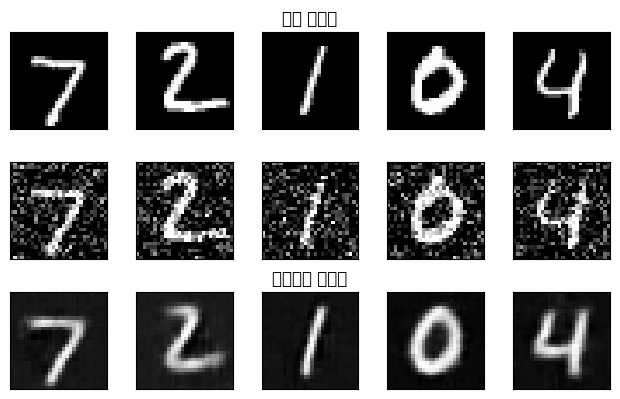

EPOCH 30/30



 EPOCH 30/30 	 train loss 0.049 	 val loss 0.038


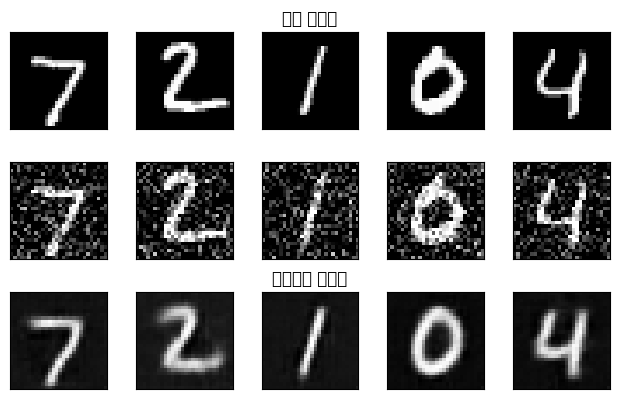

In [15]:
# 모델 학습

import numpy as np

num_epochs = 30
history_da = {'train_loss':[], 'val_loss': []}
loss_fn = torch.nn.MSELoss()

for epoch in range(num_epochs):
  print('EPOCH %d/%d' % (epoch + 1, num_epochs))
  train_loss = train_epoch(
      encoder = encoder,
      decoder = decoder,
      device = device,
      dataloader = train_loader,
      loss_fn = loss_fn,
      optimizer = optim, noise_factor = 0.3) # 모델 학습 함수(train_epoch)를 이용하여 모델 학습
  val_loss = test_epoch(
      encoder = encoder, decoder = decoder,
      device = device, dataloader = test_loader,
      loss_fn = loss_fn, noise_factor = 0.3) # 모델 검증(테스트) 함수(test_epoch)를 이용하여 테스트
  history_da['train_loss'].append(train_loss)
  history_da['val_loss'].append(val_loss)
  print('\n EPOCH {}/{} \t train loss {:.3f} \t val loss {:.3f}'.format(epoch + 1,
                                                                        num_epochs, train_loss, val_loss))
  plot_ae_outputs(encoder, decoder, noise_factor = 0.3)

## 13.2.2 변형 오토인코더

변형 오토인코더를 좀 더 쉽게 이해할 수 있게 오토인코더와 비교하면서 설명하겠다. 오토인코더는 다음 그림과 같이 입력(숫자 2)->인코더->압축(차원 축소)->디코더->출력(숫자 2)이 나오게 하는 방법이다.

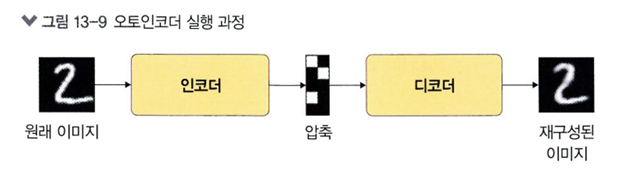

오토인코더는 차워을 줄이는 것이 목표이기 때문에 새롭게 생성된 데이터의 확률 분포에는 관심이 없다.

반면 변형 오토인코더는 표준편차와 평균을 이용하여 확률 분포를 만들고, 거기에서 샘플링하여 디코더를 통과시킨 후 새로운 데이터를 만들어 낸다. 즉, 변형 오토인코더는 입력 데이터와 조금 다른 출력 데이터를 만들어 내는데, 이때 $z$라는 가우시안 분포를 이용한다($z$를 잠재 벡터라고 한다). 중요한 특성의 파라미터를 담고 있는 $z$ 분포에서 벡터를 랜덤하게 샘플링하고 이 분포의 오차를 이용하여 입력 데이터와 유사한 다양한 데이터를 만들어 내는 것이 변형 오토인코더이다.

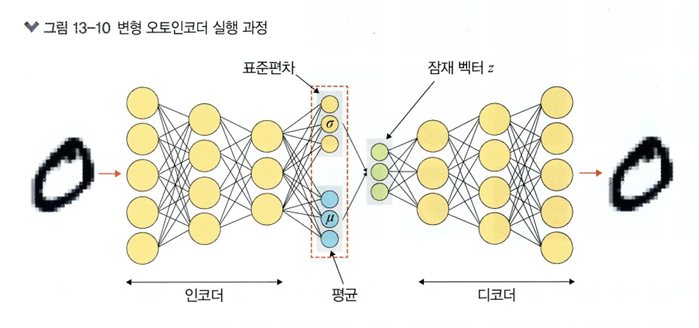



오토인코더는 데이터 벡터에 대한 차원을 축소하여 실제 이미지와 동일한 이미지를 출력하는 것이 목적이었다면, 변형 오토인코더는 데이터가 만들어지는 확률 분포를 찾아 비슷한 데이터를 생
성하는 것이 목적이다.

변형 오토인코더에서 인코더와 디코더에 대한 네트워크는 다음 그림과 같다.

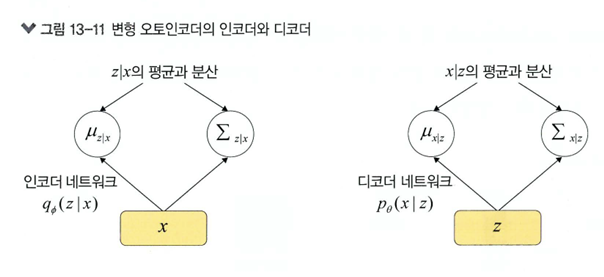

* $q_\phi (z|x)$: $x$를 입력받아 잠재 벡터 $z$ㄹ와 대응되는 평균과 분산을 구하는 네트워크로 인코더 네트워크를 의미한다.

* $q_\theta (x|z)$: $z$를 입력받아 $x$와 대응되는 평균과 분산을 구하는 네트워크로 디코더 네트워크를 의미한다.

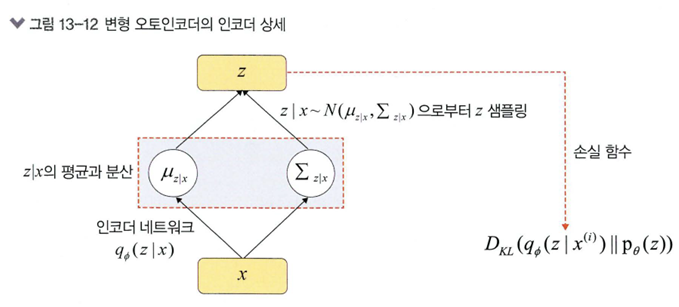



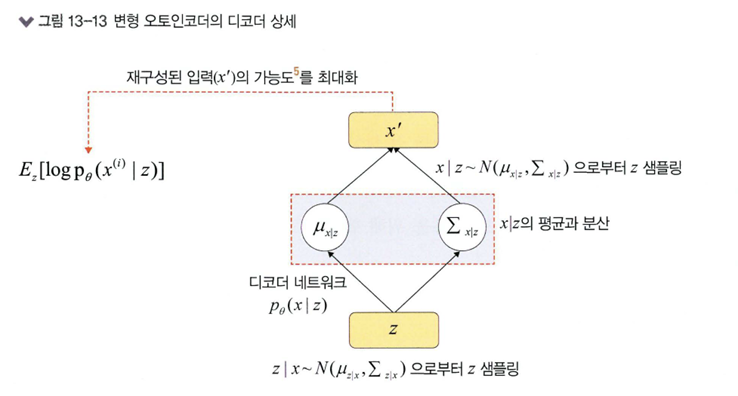

In [17]:
pip install tensorboardX

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 4.1 MB/s eta 0:00:00


In [19]:
# 필요한 라이브러리 호출

import datetime
import os
from tensorboardX import SummaryWriter

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pylab as plt

import torchvision.datasets as datasets
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [20]:
# 데이터셋을 내려받은 후 텐서 변환

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='../chap13/data', train=True, download=True, transform=transform)

test_dataset = datasets.MNIST(root='../chap13/data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True, num_workers=4, pin_memory=False)

test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False, num_workers=4)

100%|██████████| 1.65M/1.65M [00:00<00:00, 3.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.16MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [21]:
# 인코더 네트워크 생성

class Encoder(nn.Module):
  def __init__(self, input_dim, hidden_dim, latent_dim):
    super(Encoder, self).__init__()
    self.input1 = nn.Linear(input_dim, hidden_dim)
    self.input2 = nn.Linear(hidden_dim, hidden_dim)
    self.mean = nn.Linear(hidden_dim, latent_dim)
    self.var = nn.Linear(hidden_dim, latent_dim)

    self.LeakyReLU = nn.LeakyReLU(0.2)
    self.training = True

  def forward(self, x):
    h_ = self.LeakyReLU(self.input1(x))
    h_ = self.LeakyReLU(self.input2(h_))
    mean = self.mean(h_)
    log_var = self.var(h_)
    return mean, log_var # 인코더 네트워크에서 평균과 분산을 반환

인코더 역할은 데이터($x$)가 주어졌을 때 디코더가 원래 데이터로 잘 복원할 수 있는 이상적인 확률 분포 $p(z|x)$를 찾는 것이다. 변형 오토인코더에서는 이상적인 확률 분포를 찾는 데 변분추론을 사용한다.

In [22]:
# 디코더 네트워크

class Decoder(nn.Module):
  def __init__(self, latent_dim, hidden_dim, output_dim):
    super(Decoder, self).__init__()
    self.hidden1 = nn.Linear(latent_dim, hidden_dim)
    self.hidden2 = nn.Linear(hidden_dim, hidden_dim)
    self.output = nn.Linear(hidden_dim, output_dim)
    self.LeakyReLU = nn.LeakyReLU(0.2)

  def forward(self, x):
    h = self.LeakyReLU(self.hidden1(x))
    h = self.LeakyReLU(self.hidden2(h))
    x_hat = torch.sigmoid(self.output(h))
    return x_hat # 디코더 결과는 시그모이드를 통과했으므로 0~1 값을 갖는다.

In [23]:
# 변형 오토인코더 네트워크

class Model(nn.Module):
  def __init__(self, Encoder, Decoder):
    super(Model, self).__init__()
    self.Encoder = Encoder
    self.Decoder = Decoder

  def reparameterization(self, mean, var):
    epsilon = torch.randn_like(var).to(device)
    z = mean + var * epsilon
    return z

  def forward(self, x):
    mean, log_var = self.Encoder(x)
    z = self.reparameterization(mean, torch.exp(0.5 * log_var))
    x_hat = self.Decoder(z)
    return x_hat, mean, log_var

In [24]:
# 인코더와 디코더 객체 초기화

x_dim = 784
hidden_dim = 400
latent_dim = 200
epochs = 30
batch_size = 100

encoder = Encoder(input_dim=x_dim, hidden_dim=hidden_dim, latent_dim=latent_dim)
decoder = Decoder(latent_dim=latent_dim, hidden_dim=hidden_dim, output_dim=x_dim)

model = Model(Encoder=encoder, Decoder=decoder).to(device)

In [25]:
# 손실 함수 정의

def loss_function(x, x_hat, mean, log_var):
  reproduction_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
  KLD = -0.5*torch.sum(1+log_var-mean.pow(2)-log_var.exp())
  return reproduction_loss, KLD

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [27]:
# 모델 학습 함수 정의

saved_loc = 'scalar/' # 텐서보드에서 사용할 경로
writer = SummaryWriter(saved_loc)

model.train()
def train(epoch, model, train_loader, optimizer):
  train_loss = 0
  for batch_idx, (x, _) in enumerate(train_loader):
    x = x.view(batch_size, x_dim)
    x = x.to(device)

    optimizer.zero_grad()
    x_hat, mean, log_var = model(x)
    BCE, KLD = loss_function(x, x_hat, mean, log_var)
    loss = BCE + KLD
    writer.add_scalar("Train/Reconstruction Error", BCE.item(), batch_idx + epoch *
                      (len(train_loader.dataset)/batch_size))
    writer.add_scalar("Train/KL-Divergence", KLD.item(), batch_idx + epoch *
                      (len(train_loader.dataset)/batch_size))
    writer.add_scalar("Train/Total Loss", loss.item(), batch_idx + epoch *
                      (len(train_loader.dataset)/batch_size))
    train_loss += loss.item()
    loss.backward()
    optimizer.step()

    if batch_idx % 100 == 0:
      print('Train Epoch: {} [{}/{} ({:.0f}%)]\t Loss: {:.6f}'.format(
          epoch, batch_idx * len(x), len(train_loader.dataset),
          100. * batch_idx / len(train_loader), loss.item() / len(x)))
  print('====> Epoch: {} Average loss: {:.4f}'.format(
      epoch, train_loss / len(train_loader.dataset)))


In [28]:
# 모델 평가 함수 정의

def test(epoch, model, test_loader):
  model.eval()
  test_loss = 0
  with torch.no_grad():
    for batch_idx, (x, _) in enumerate(test_loader):
      x = x.view(batch_size, x_dim)
      x = x.to(device)
      x_hat, mean, log_var = model(x)
      BCE, KLD = loss_function(x, x_hat, mean, log_var)
      loss = BCE + KLD

      writer.add_scalar("Test/Reconstruction Error", BCE.item(), batch_idx +
                        epoch * (len(test_loader.dataset)/batch_size)) # 테스트 데이터셋에 대해서도 오차를 로그에 저장
      writer.add_scalar("Test/KL-Divergence", KLD.item(), batch_idx + epoch *
                        (len(test_loader.dataset)/batch_size))
      writer.add_scalar("Test/Total Loss", loss.item(), batch_size + epoch *
                        (len(test_loader.dataset)/batch_size))
      test_loss += loss.item()

      if batch_idx == 0:
        n = min(x.size(0), 8)
        comparison = torch.cat([x[:n], x_hat.view(batch_size, x_dim)[:n]])
        grid = torchvision.utils.make_grid(comparison.cpu())
        writer.add_image("Test image - Above: Real data, below: reconstruction data", grid, epoch)

In [29]:
# 모델 학습

from tqdm import tqdm
for epoch in tqdm(range(0, epochs)):
  train(epoch, model, train_loader, optimizer)
  test(epoch, model, test_loader)
  print("\n")
writer.close()

  0%|          | 0/30 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Train Epoch: 0 [0/60000 (0%)]	 Loss: 545.600430
Train Epoch: 0 [10000/60000 (17%)]	 Loss: 196.443418
Train Epoch: 0 [20000/60000 (33%)]	 Loss: 186.522832
Train Epoch: 0 [30000/60000 (50%)]	 Loss: 157.959258
Train Epoch: 0 [40000/60000 (67%)]	 Loss: 156.088955
Train Epoch: 0 [50000/60000 (83%)]	 Loss: 138.664453
====> Epoch: 0 Average loss: 172.9115


  3%|▎         | 1/30 [00:25<12:13, 25.28s/it]



Train Epoch: 1 [0/60000 (0%)]	 Loss: 139.196807
Train Epoch: 1 [10000/60000 (17%)]	 Loss: 132.159902
Train Epoch: 1 [20000/60000 (33%)]	 Loss: 134.661338
Train Epoch: 1 [30000/60000 (50%)]	 Loss: 129.134580
Train Epoch: 1 [40000/60000 (67%)]	 Loss: 133.018184
Train Epoch: 1 [50000/60000 (83%)]	 Loss: 118.471260
====> Epoch: 1 Average loss: 128.7082


  7%|▋         | 2/30 [00:47<11:01, 23.63s/it]

...

 93%|█████████▎| 28/30 [10:27<00:44, 22.40s/it]



Train Epoch: 28 [0/60000 (0%)]	 Loss: 98.685537
Train Epoch: 28 [10000/60000 (17%)]	 Loss: 99.866641
Train Epoch: 28 [20000/60000 (33%)]	 Loss: 102.847588
Train Epoch: 28 [30000/60000 (50%)]	 Loss: 100.357598
Train Epoch: 28 [40000/60000 (67%)]	 Loss: 95.619707
Train Epoch: 28 [50000/60000 (83%)]	 Loss: 102.335488
====> Epoch: 28 Average loss: 100.2399


 97%|█████████▋| 29/30 [10:48<00:22, 22.15s/it]



Train Epoch: 29 [0/60000 (0%)]	 Loss: 99.170117
Train Epoch: 29 [10000/60000 (17%)]	 Loss: 104.744863
Train Epoch: 29 [20000/60000 (33%)]	 Loss: 101.490264
Train Epoch: 29 [30000/60000 (50%)]	 Loss: 97.124766
Train Epoch: 29 [40000/60000 (67%)]	 Loss: 98.533291
Train Epoch: 29 [50000/60000 (83%)]	 Loss: 101.374229
====> Epoch: 29 Average loss: 100.1782


100%|██████████| 30/30 [11:14<00:00, 22.47s/it]

In [30]:
# 텐서보드에서 오차 확인

%load_ext tensorboard
%tensorboard --logdir scalar --port = 6013

ERROR: Failed to launch TensorBoard (exited with 2).
Contents of stderr:
2026-05-25 08:42:40.173641: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-25 08:42:42.490152: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
usage: tensorboard [-h] [--helpfull] [--logdir PATH] [--logdir_spec PATH_SPEC]
                   [--host ADDR] [--bind_all] [--port PORT]
                   [--reuse_port BOOL] [--load_fast {false,auto,true}]
                   [--extra_data_server_flags EXTRA_DATA_SERVER_FLAGS]
                   [--grpc_creds_type {local,ssl,ssl_dev}]
                   [--grpc_data_provider PORT] [--purge_orphaned_data BOOL]
                   [--db URI] [--db_import] [--insp

오차 결과 KLD와 재구성 오차가 반비례하면서 전체 오차는 에포크가 진행될수록 작아지는 것을 확인할 수 있다. 재구성 오차가 감소하고 있는 것으로 보아 기존 이미지를 이용한 새로운 이미지 생성이 잘 진행되고 있음을 유추해 볼 수 있다.

훈련 데이터셋과 마찬가지로 KLD와 재구성 오치는 반비례 관계를 가지며 전체 오차는 에포크가 진행되면서 줄어들고 있다. 기존 이미지를 이용한 새로운 이미지가 잘 생성되고 있음을 의미한다.